In [1]:
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import *
import itertools

import warnings
warnings.filterwarnings("ignore")

#### Importing the dataset comprising data of children with illegal immigration status or no parent or guardian

In [2]:
df = pd.read_csv("HHS_Unaccompanied_Alien_Children_Program.csv")
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,21-Dec-25,6,18,11,"2,484",14
1,18-Dec-25,11,50,6,"2,472",16
2,17-Dec-25,7,31,11,"2,481",10
3,16-Dec-25,8,54,15,"2,468",9
4,15-Dec-25,11,42,9,"2,470",7


#### Checking for null values and duplicates

In [3]:
df.isna().sum()

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

#### Converting data to pandas date-time format

In [5]:
df["Date"] = pd.to_datetime(df["Date"])
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2025-12-21,6,18,11,"2,484",14
1,2025-12-18,11,50,6,"2,472",16
2,2025-12-17,7,31,11,"2,481",10
3,2025-12-16,8,54,15,"2,468",9
4,2025-12-15,11,42,9,"2,470",7


#### Arrange dates in ascending order

In [6]:
df.sort_values(by=["Date"], inplace=True)
df.reset_index(drop=True, inplace=True)
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33,53,34,"6,566",436
1,2023-01-22,32,49,39,"7,122",227
2,2023-01-23,32,50,39,"7,280",181
3,2023-01-24,47,42,47,"7,433",175
4,2023-01-25,20,22,41,"7,538",180


#### Retrieving weekday names for each date in the dataset

In [7]:
df["Day of Week"] = list(map(lambda x: x.strftime("%A"), df["Date"]))
df = df[["Date","Day of Week","Children apprehended and placed in CBP custody*","Children in CBP custody","Children transferred out of CBP custody","Children in HHS Care","Children discharged from HHS Care"]]
df.head()

,Date,Day of Week,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,Thursday,33,53,34,"6,566",436
1,2023-01-22,Sunday,32,49,39,"7,122",227
2,2023-01-23,Monday,32,50,39,"7,280",181
3,2023-01-24,Tuesday,47,42,47,"7,433",175
4,2023-01-25,Wednesday,20,22,41,"7,538",180


#### Finding out the total number of records on each day of week

In [8]:
weekday_number = df["Day of Week"].value_counts().reset_index()
weekday_number["Day of Week Number"] = weekday_number["Day of Week"].map({
    "Sunday": "1",
    "Monday": "2",
    "Tuesday": "3",
    "Wednesday": "4",
    "Thursday": "5",
    "Friday": "6",
    "Saturday": "7"
})
weekday_number = weekday_number.sort_values(by=["Day of Week Number"]).reset_index(drop=True)
weekday_number

,Day of Week,count,Day of Week Number
0,Sunday,130,1
1,Monday,145,2
2,Tuesday,149,3
3,Wednesday,147,4
4,Thursday,147,5
5,Friday,2,6


Looking at the numbers above, we can see that the number of days on which children were recorded is relatively consistent from Sunday through Thursday. From Monday through Thursday, the figures range between 145 and 150 days. Sunday is somewhat lower, at 130 days, but it is still reasonably close to this range.

Friday, however, stands out as an exceptionally low number of recorded days. Data is recorded for only two Fridays, compared with more than 130 recorded days for each of the other weekdays. This substantial difference suggests that Friday may represent a distinct pattern in the data and warrants further investigation.

There is one assumption that we can make here, which is deleting those two Friday records and assuming that services are not provided on Fridays and Saturdays. But in reality, these services are provided 24 hours a day and 7 days a week. So we need to include these days on which data is not recorded and then somehow deal with the null values for number of children on these days.

#### Creating a new dataset with dates on which  data is not recorded

In [9]:
df_2 = pd.DataFrame(columns=df.columns)
df_2["Date"] = np.setdiff1d(pd.date_range(df["Date"].min(),df["Date"].max()).values,df["Date"].values)
df_2["Day of Week"] = list(map(lambda x: x.strftime("%A"), df_2["Date"]))
df_2[['Children apprehended and placed in CBP custody*','Children in CBP custody','Children transferred out of CBP custody','Children in HHS Care', 'Children discharged from HHS Care']] = np.nan
df_2.head()

,Date,Day of Week,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-13,Friday,NaN,NaN,NaN,NaN,NaN
1,2023-01-14,Saturday,NaN,NaN,NaN,NaN,NaN
2,2023-01-15,Sunday,NaN,NaN,NaN,NaN,NaN
3,2023-01-16,Monday,NaN,NaN,NaN,NaN,NaN
4,2023-01-17,Tuesday,NaN,NaN,NaN,NaN,NaN


#### Concatenating the original dataset with the new dataset comprising unrecorded dates

In [10]:
df_3 = pd.concat([df,df_2]).sort_values(by=["Date"]).reset_index(drop=True)
df_3.drop(columns=["Day of Week"], inplace=True)
df_3.set_index("Date", inplace=True)
df_3.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,"6,566",436.0
2023-01-13,NaN,NaN,NaN,NaN,NaN
2023-01-14,NaN,NaN,NaN,NaN,NaN
2023-01-15,NaN,NaN,NaN,NaN,NaN
2023-01-16,NaN,NaN,NaN,NaN,NaN


#### Checking the data types of each feature

In [11]:
df_3.dtypes

Children apprehended and placed in CBP custody*    float64
Children in CBP custody                            float64
Children transferred out of CBP custody            float64
Children in HHS Care                                object
Children discharged from HHS Care                  float64
dtype: object

As we observe the above data types, the feature *Children in HHS care* is of object type. The other features are of float type. In reality, these features denote number of children going through their respective stage. This means that such features ought to be integers.

All the features except the *Children in HHS Care* are floating points, which makes it unnecessary for us to convert into integers, as they are of numeric type. The values for such features end with ".0". The *Children in HHS Care* is of object type, which is a non-numeric type - this forces us to convert it to numeric type. Before type conversion, let us see how the values of *Children in HHS Care* look like:

In [12]:
print(df_3["Children in HHS Care"].unique().tolist())

['6,566', nan, '7,122', '7,280', '7,433', '7,538', '7,472', '7,743', '7,803', '7,903', '7,879', '7,586', '7,720', '7,855', '7,915', '7,908', '7,434', '7,483', '7,794', '7,869', '7,793', '7,817', '7,967', '7,978', '7,914', '7,609', '7,800', '7,896', '7,930', '7,870', '7,859', '7,885', '7,786', '7,567', '7,810', '7,989', '7,931', '8,050', '8,097', '8,102', '7,847', '7,994', '8,079', '8,208', '8,158', '7,981', '8,054', '8,068', '8,175', '8,178', '7,900', '7,826', '7,922', '7,876', '7,795', '7,380', '7,344', '7,376', '7,356', '7,490', '7,534', '7,796', '8,017', '8,117', '8,159', '8,352', '8,492', '8,654', '8,704', '8,790', '8,485', '8,590', '8,606', '8,681', '8,672', '8,445', '8,571', '8,572', '8,569', '8,474', '7,848', '7,788', '7,709', '7,546', '6,996', '7,046', '7,053', '7,002', '6,555', '6,523', '6,508', '6,483', '6,446', '6,007', '6,021', '6,061', '6,065', '6,038', '5,679', '5,904', '5,922', '5,956', '5,766', '5,819', '5,917', '5,999', '6,058', '5,903', '6,127', '6,193', '6,239', '6,2

As we observe, there are commas in each element of *Children in HHS Care* column. We need to remove those commas and convert the data type into floating point so that the data type matches with that of other columns.

In [13]:
df_4 = df_3.copy()

df_4["Children in HHS Care"] = list(map(lambda x: "".join(x.split(",")), df_4["Children in HHS Care"]))

AttributeError: 'float' object has no attribute 'split'

From the above error, we can say that there are some floating point values for the column *Children in HHS Care*. We need to explicitly convert all values to string, then remove those commas and then convert them to floating point.

In [14]:
df_4["Children in HHS Care"] = list(map(lambda x: "".join(str(x).split(",")),df_4["Children in HHS Care"]))
df_4["Children in HHS Care"] = df_4["Children in HHS Care"].astype("float64")
df_4.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,NaN,NaN,NaN,NaN,NaN
2023-01-14,NaN,NaN,NaN,NaN,NaN
2023-01-15,NaN,NaN,NaN,NaN,NaN
2023-01-16,NaN,NaN,NaN,NaN,NaN


Now, let us make use of data interpolation, which figures out values for each null value by itself based on non-null values around each of them.

In [15]:
df_4 = df_4.interpolate().copy()
df_4.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,32.9,52.6,34.5,6621.6,415.1
2023-01-14,32.8,52.2,35.0,6677.2,394.2
2023-01-15,32.7,51.8,35.5,6732.8,373.3
2023-01-16,32.6,51.4,36.0,6788.4,352.4


As we observe the above dataset, the values are in decimal points. In reality the features denote number of children in each phase - this means that the elements should also be integers. So, we shall round all the elements to their nearest integers.

In [16]:
df_5 = df_4.round(0)
df_5.head()

,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
Date,,,,,
2023-01-12,33.0,53.0,34.0,6566.0,436.0
2023-01-13,33.0,53.0,34.0,6622.0,415.0
2023-01-14,33.0,52.0,35.0,6677.0,394.0
2023-01-15,33.0,52.0,36.0,6733.0,373.0
2023-01-16,33.0,51.0,36.0,6788.0,352.0


Now, we need to have a look for patterns for each column. The best way is to visualise the data.

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
df_6 = df_5.reset_index()
df_6.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0


Let us export the data to a CSV file. We shall perform data visualisation in Tableau.

In [19]:
df_6.to_csv("HHS_Program_Cleaned.csv")

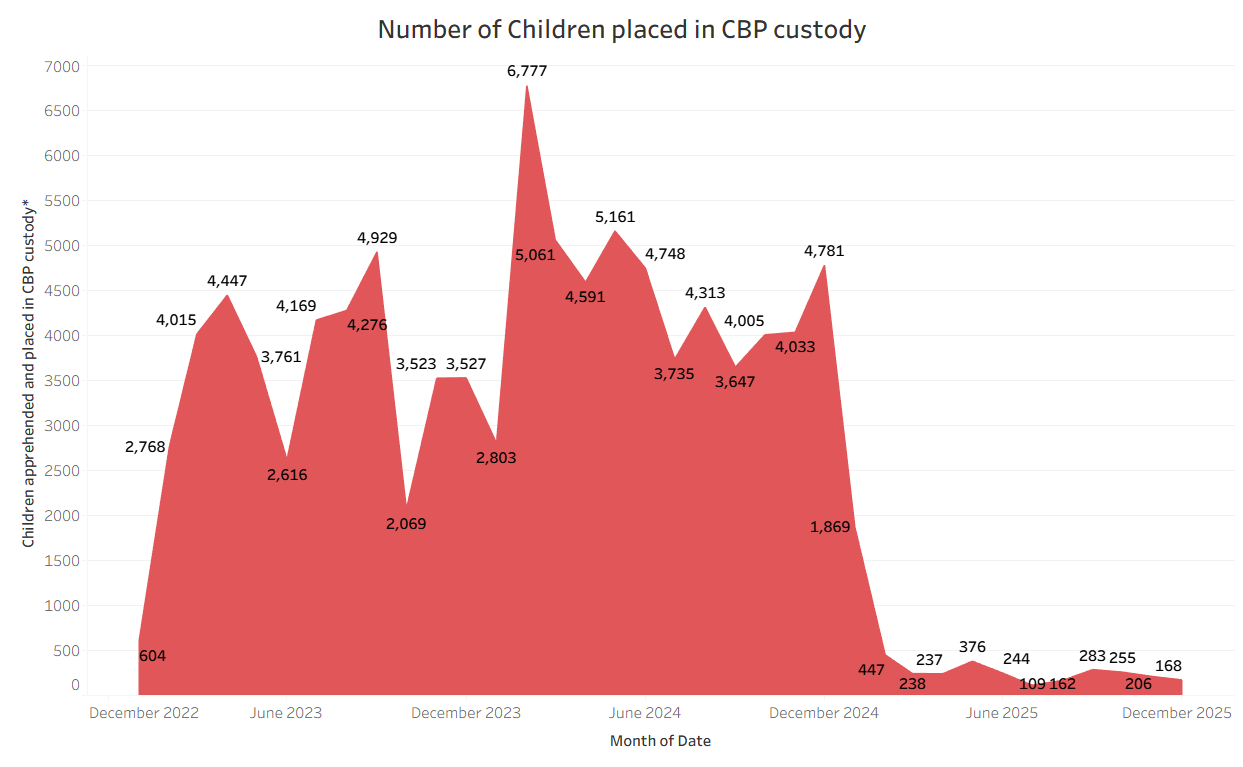

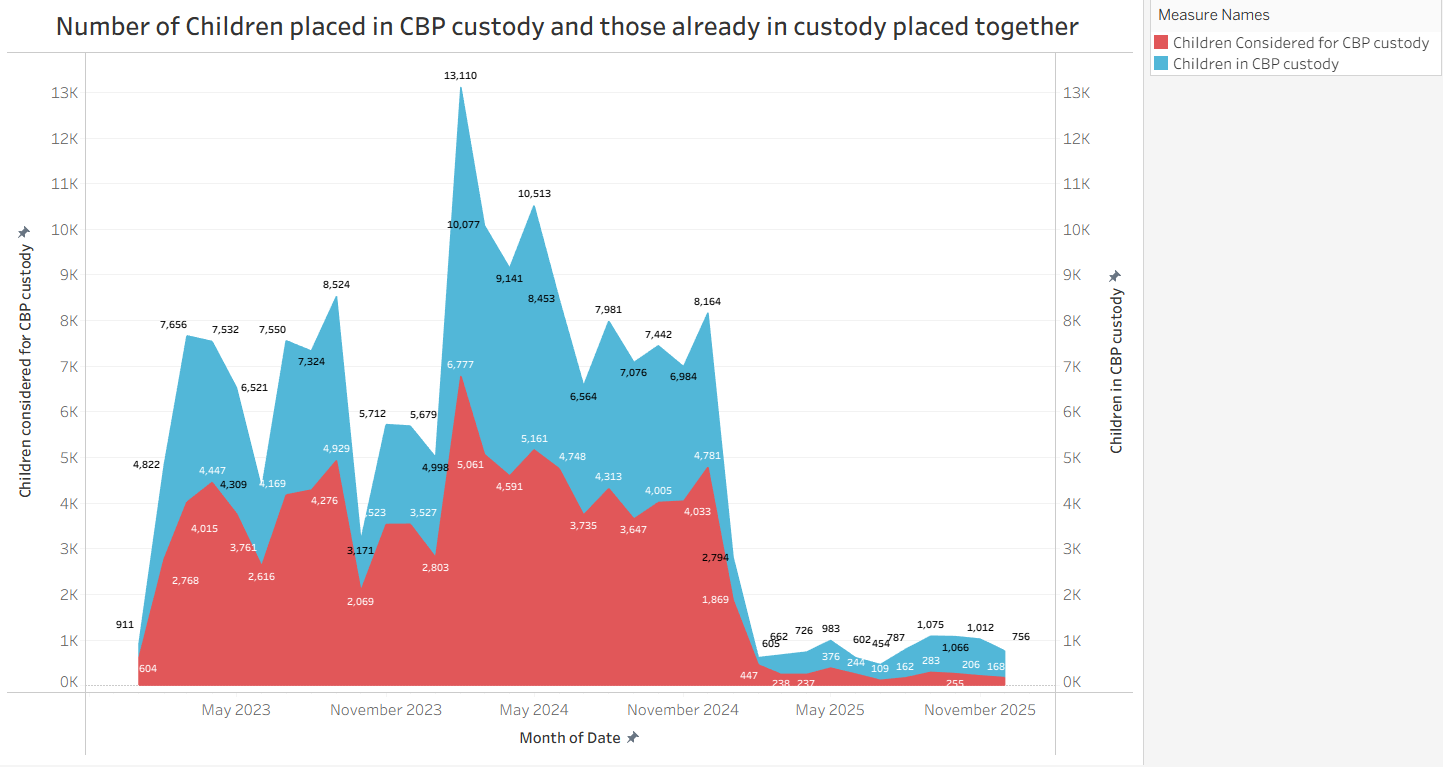
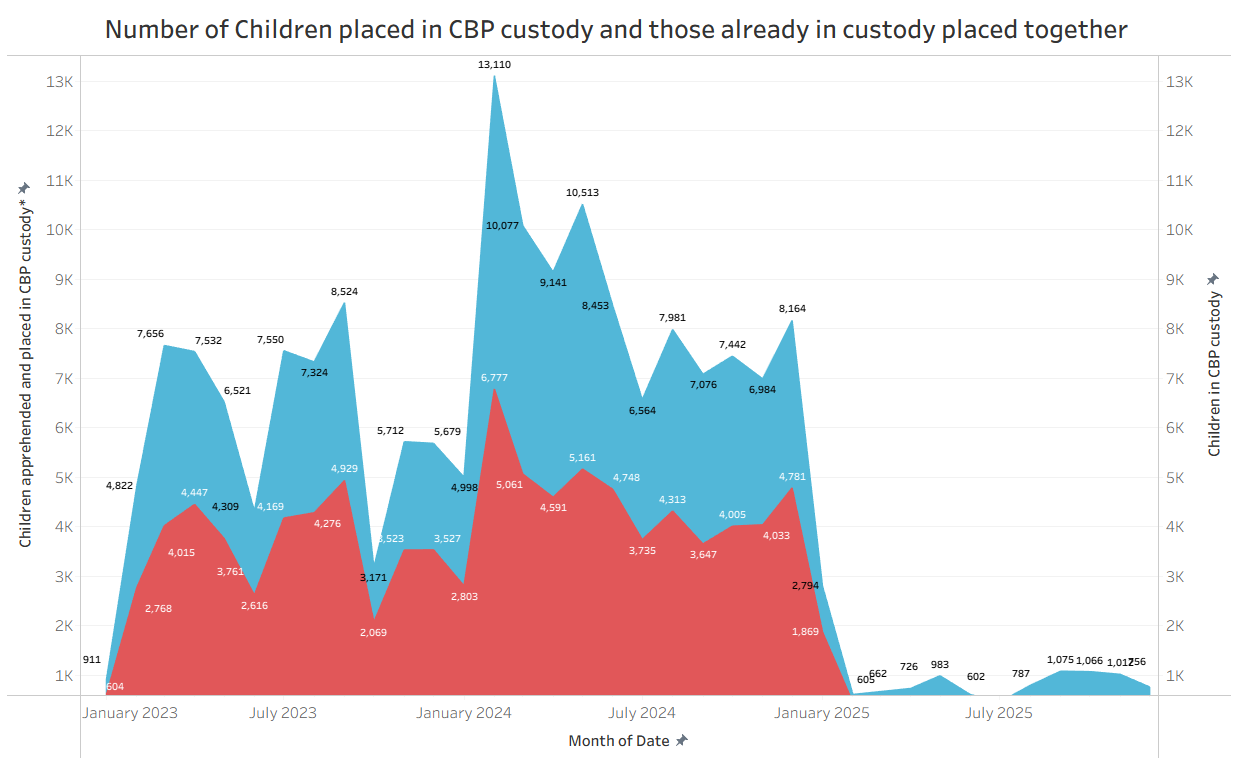

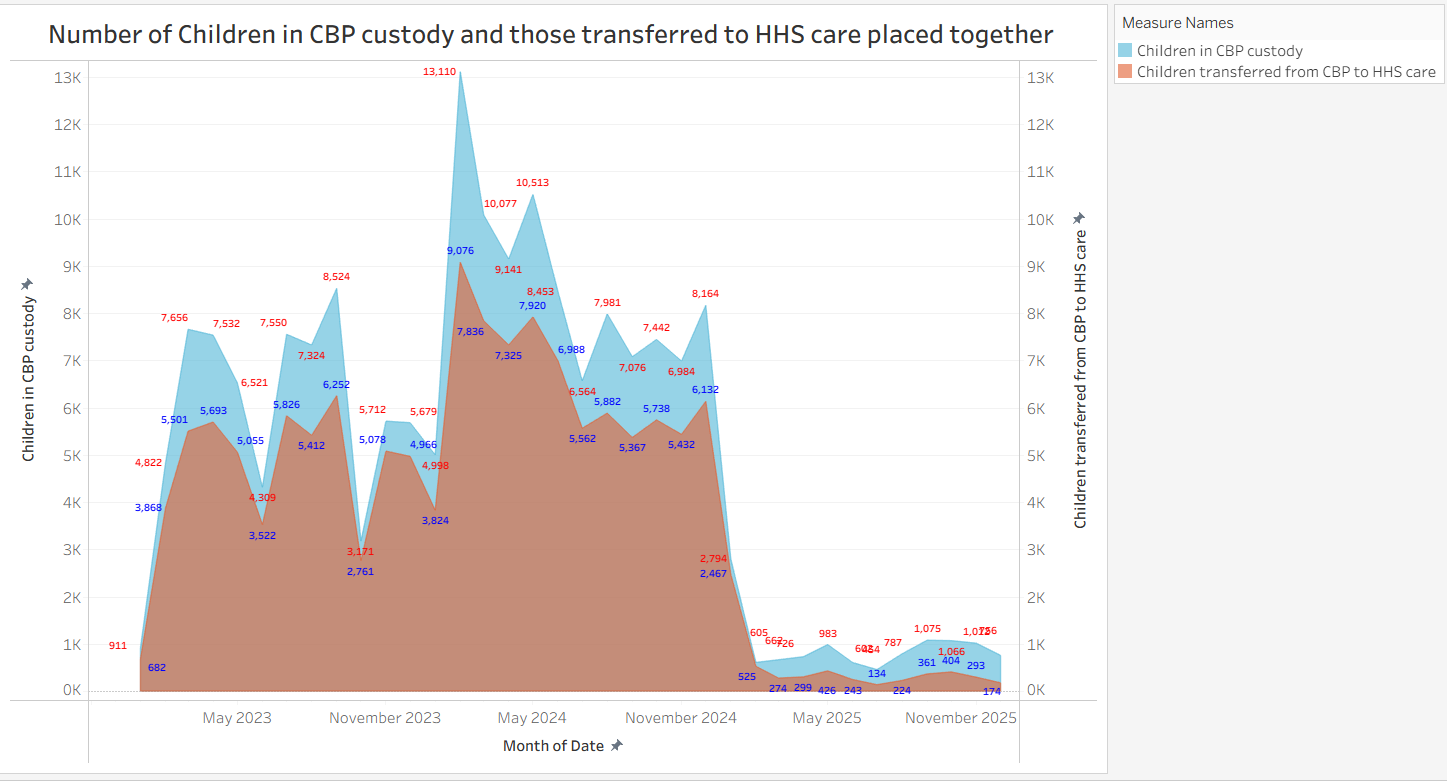
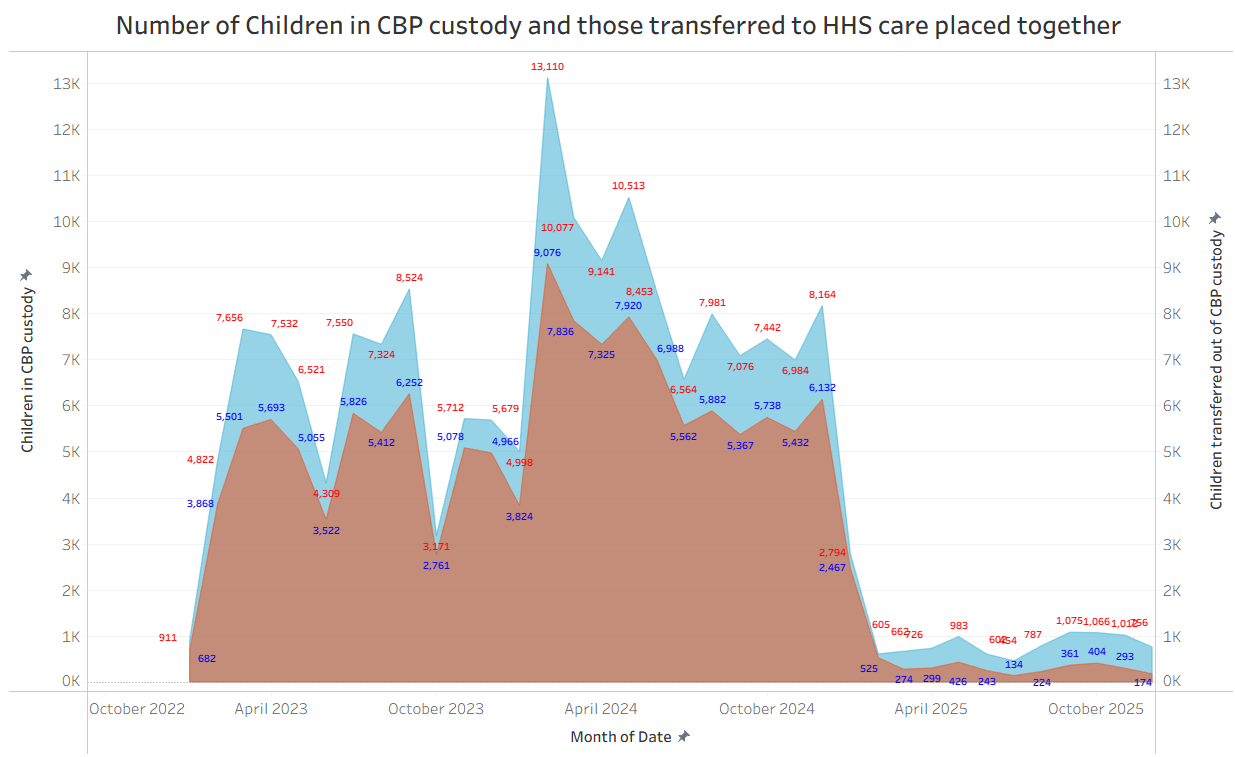
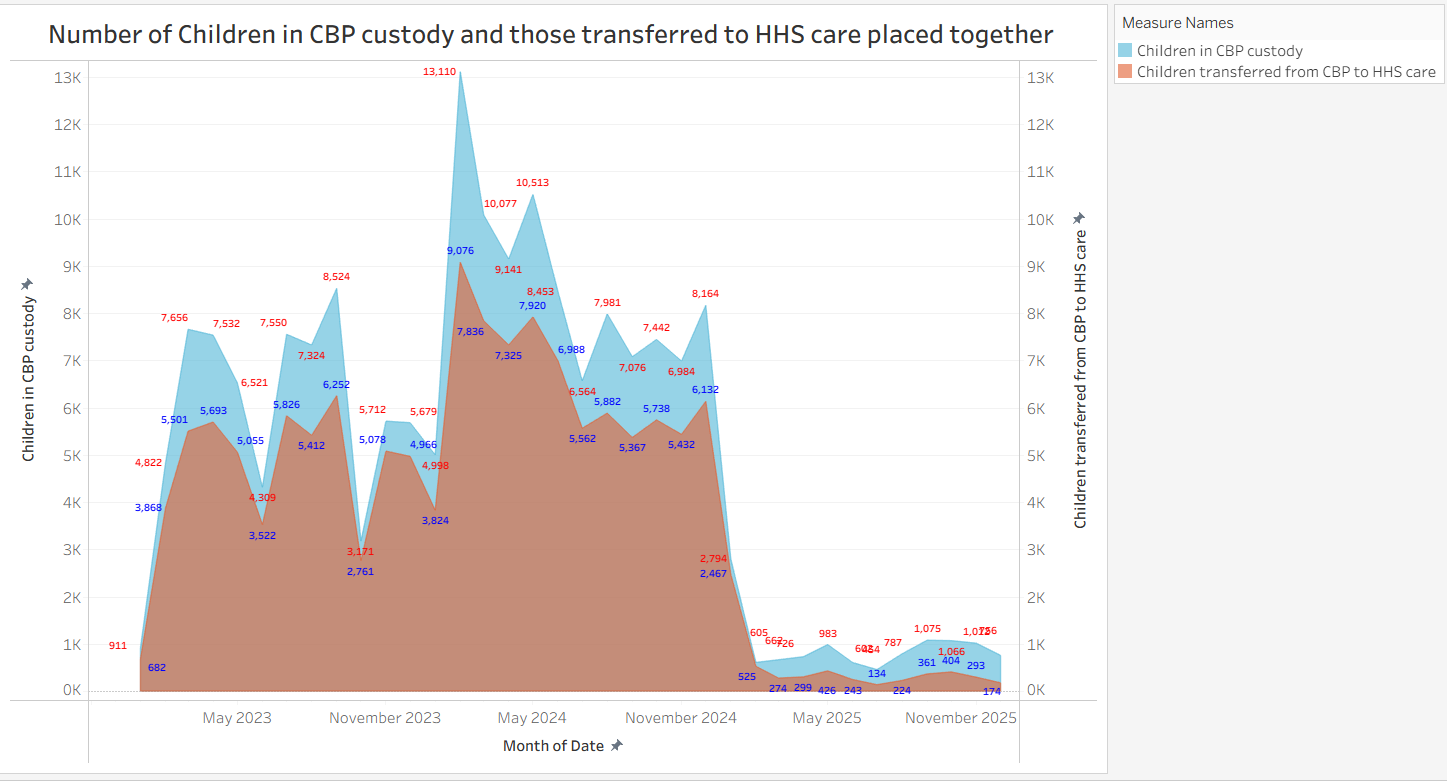

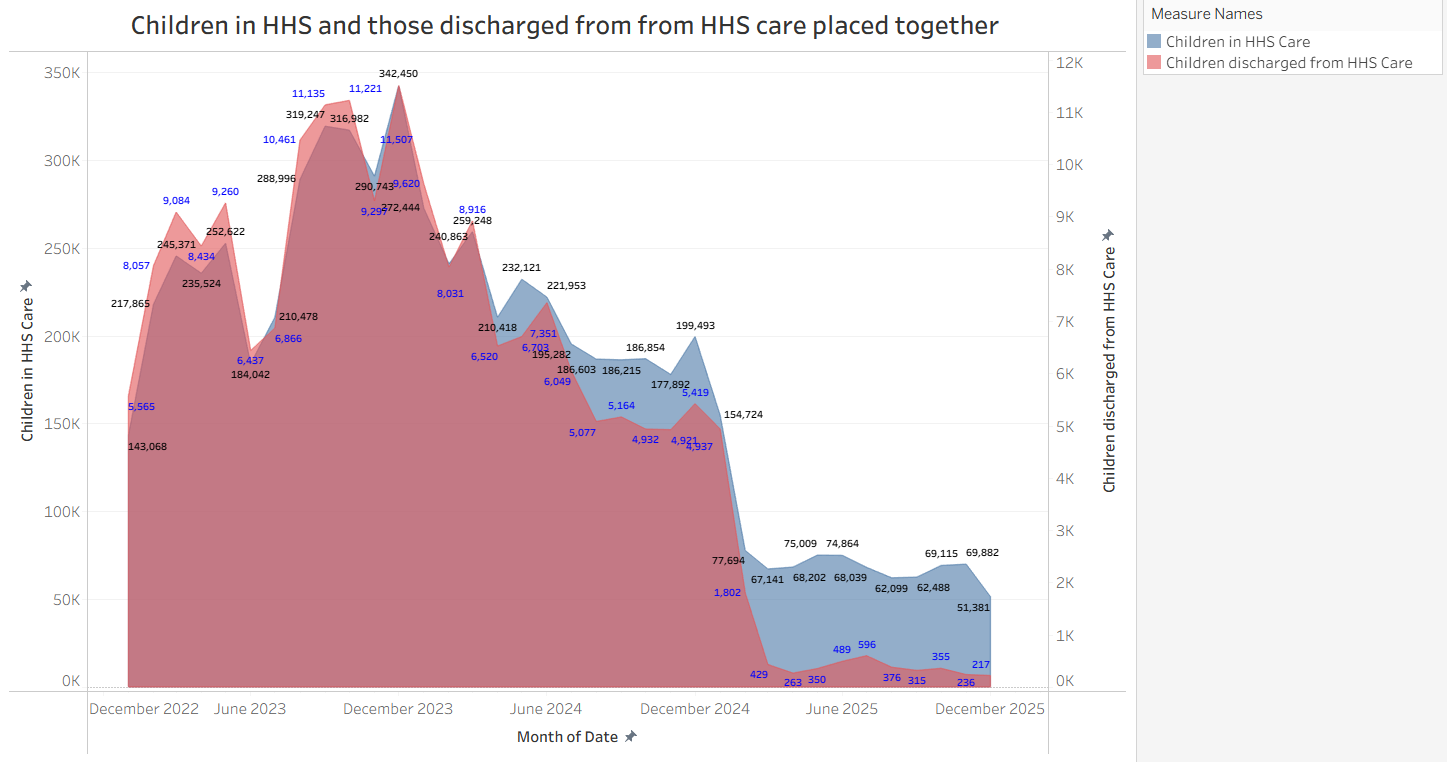

From the above graphs, we can infer that Children who were considered by CBP, those already going through CBP custody and those done with the CBP custody and transferred to HHS care follow a very similar pattern. Same is the case with the children in HHS care and those who got discharged from it.

There is another important aspect extracted from the dataset. The number of children undergoing each phase of the program has gone drastically down in February 2025, and the same level is maintained throughout the rest of the time. This is mainly due to decrease in illegal immigration to the United States, thanks to harsh restrictions set up by the Trump government. Trump came into power on January 20, 2025. Some of his initial executive orders include crackdown of illegal immigration - this is the main driver behind numbers falling down.

#### Detecting Outliers using Interquartile Range Method

In [20]:
df_temp = df_6.drop(columns="Date")

Q1 = df_temp.quantile(0.25) # Lower Quartile
Q3 = df_temp.quantile(0.75) # Upper Quartile

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

df_temp[(df_temp < lower_limit) | (df_temp > upper_limit)].sum()

Children apprehended and placed in CBP custody*    0.0
Children in CBP custody                            0.0
Children transferred out of CBP custody            0.0
Children in HHS Care                               0.0
Children discharged from HHS Care                  0.0
dtype: float64

As we observe, there are no values below the lower limit and above the upper limit. This means that there are no outliers at all in our dataset.

In [21]:
df_6.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0


#### Renaming all columns to simple names

In [22]:
df_7 = df_6.copy()
df_7.rename(columns={
    "Date" : "Date",
    "Children apprehended and placed in CBP custody*" : "Placed_In_CBP",
    "Children in CBP custody" : "CBP_Custody",
    "Children transferred out of CBP custody" : "CBP_To_HHS",
    "Children in HHS Care"	: "HHS_Care",
    "Children discharged from HHS Care": "Discharged_From_HHS"
},inplace=True)

df_7.head()

,Date,Placed_In_CBP,CBP_Custody,CBP_To_HHS,HHS_Care,Discharged_From_HHS
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0


#### Creating lags and rolling averages for each column

In [23]:
# Retrieving all parameters of children
list_of_columns = df_7.columns.values.tolist()[1:]

# New Lag Columns
lag_by_1 = [i+"_lag_1" for i in list_of_columns]
lag_by_7 = [i+"_lag_7" for i in list_of_columns]
lag_by_14 = [i+"_lag_14" for i in list_of_columns]

# Columns for Rolling averages
rolling_avg_7 = [i+"_rolling_avg_7" for i in list_of_columns]
rolling_avg_14 = [i+"_rolling_avg_14" for i in list_of_columns]

# Calculating lag features
df_7[lag_by_1] = df_7[list_of_columns].shift(1)
df_7[lag_by_7] = df_7[list_of_columns].shift(7)
df_7[lag_by_14] = df_7[list_of_columns].shift(14)

# Calculating rolling averages
df_7[rolling_avg_7] = df_7[list_of_columns].rolling(7).mean()
df_7[rolling_avg_14] = df_7[list_of_columns].rolling(14).mean()

In [24]:
df_7.head(5)

,Date,Placed_In_CBP,CBP_Custody,CBP_To_HHS,HHS_Care,Discharged_From_HHS,Placed_In_CBP_lag_1,CBP_Custody_lag_1,CBP_To_HHS_lag_1,HHS_Care_lag_1,...,Placed_In_CBP_rolling_avg_7,CBP_Custody_rolling_avg_7,CBP_To_HHS_rolling_avg_7,HHS_Care_rolling_avg_7,Discharged_From_HHS_rolling_avg_7,Placed_In_CBP_rolling_avg_14,CBP_Custody_rolling_avg_14,CBP_To_HHS_rolling_avg_14,HHS_Care_rolling_avg_14,Discharged_From_HHS_rolling_avg_14
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0,33.0,53.0,34.0,6566.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0,33.0,53.0,34.0,6622.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0,33.0,52.0,35.0,6677.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0,33.0,52.0,36.0,6733.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Defining Flow based signals

In [25]:
# Defining the net flow of children right from entering HHS care to discharging them
df_7["Net_HHS_Flow"] = df_7["CBP_To_HHS"] - df_7["Discharged_From_HHS"]

# Rolling averages of Net HHS
df_7["Net_HHS_Flow_rolling_avg_7"] = df_7["Net_HHS_Flow"].rolling(7).mean()
df_7["Net_HHS_Flow_rolling_avg_14"] = df_7["Net_HHS_Flow"].rolling(14).mean()

# Rolling standard deviation across 7 days
df_7["Net_HHS_Flow_rolling_std_7"] = df_7["Net_HHS_Flow"].rolling(7).std()


df_7.head()

,Date,Placed_In_CBP,CBP_Custody,CBP_To_HHS,HHS_Care,Discharged_From_HHS,Placed_In_CBP_lag_1,CBP_Custody_lag_1,CBP_To_HHS_lag_1,HHS_Care_lag_1,...,Discharged_From_HHS_rolling_avg_7,Placed_In_CBP_rolling_avg_14,CBP_Custody_rolling_avg_14,CBP_To_HHS_rolling_avg_14,HHS_Care_rolling_avg_14,Discharged_From_HHS_rolling_avg_14,Net_HHS_Flow,Net_HHS_Flow_rolling_avg_7,Net_HHS_Flow_rolling_avg_14,Net_HHS_Flow_rolling_std_7
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,-402.0,NaN,NaN,NaN
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0,33.0,53.0,34.0,6566.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-381.0,NaN,NaN,NaN
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0,33.0,53.0,34.0,6622.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-359.0,NaN,NaN,NaN
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0,33.0,52.0,35.0,6677.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-337.0,NaN,NaN,NaN
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0,33.0,52.0,36.0,6733.0,...,NaN,NaN,NaN,NaN,NaN,NaN,-316.0,NaN,NaN,NaN


Flow acceleration is just an additional and a useful feature, but not mandatory. It is just to determine how inflow pressure changes as days pass on

#### Adding calender effects

In [26]:
# Day of Week
df_7["Day_Of_Week"] = df_7["Date"].dt.dayofweek

# Month
df_7["Month"] = df_7["Date"].dt.month

# If the day is weekend or not
df_7["Is_Weekend"] = (df_7["Day_Of_Week"] >= 5).astype("int64")

df_7.head(8)

,Date,Placed_In_CBP,CBP_Custody,CBP_To_HHS,HHS_Care,Discharged_From_HHS,Placed_In_CBP_lag_1,CBP_Custody_lag_1,CBP_To_HHS_lag_1,HHS_Care_lag_1,...,CBP_To_HHS_rolling_avg_14,HHS_Care_rolling_avg_14,Discharged_From_HHS_rolling_avg_14,Net_HHS_Flow,Net_HHS_Flow_rolling_avg_7,Net_HHS_Flow_rolling_avg_14,Net_HHS_Flow_rolling_std_7,Day_Of_Week,Month,Is_Weekend
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-402.0,NaN,NaN,NaN,3,1,0
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0,33.0,53.0,34.0,6566.0,...,NaN,NaN,NaN,-381.0,NaN,NaN,NaN,4,1,0
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0,33.0,53.0,34.0,6622.0,...,NaN,NaN,NaN,-359.0,NaN,NaN,NaN,5,1,1
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0,33.0,52.0,35.0,6677.0,...,NaN,NaN,NaN,-337.0,NaN,NaN,NaN,6,1,1
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0,33.0,52.0,36.0,6733.0,...,NaN,NaN,NaN,-316.0,NaN,NaN,NaN,0,1,0
5,2023-01-17,32.0,51.0,36.0,6844.0,332.0,33.0,51.0,36.0,6788.0,...,NaN,NaN,NaN,-296.0,NaN,NaN,NaN,1,1,0
6,2023-01-18,32.0,51.0,37.0,6900.0,311.0,32.0,51.0,36.0,6844.0,...,NaN,NaN,NaN,-274.0,-337.857143,NaN,46.063104,2,1,0
7,2023-01-19,32.0,50.0,38.0,6955.0,290.0,32.0,51.0,37.0,6900.0,...,NaN,NaN,NaN,-252.0,-316.428571,NaN,46.140572,3,1,0


#### Time-Series Decomposition

In [27]:
decomp = seasonal_decompose(
    x = df_7["HHS_Care"],
    model = "additive",
    period = 7
)

In [28]:
decomp_df = pd.DataFrame(columns=["Date","Observed","Seasonal","Trend","Residual"])
decomp_df["Date"] = df_7["Date"].copy()
decomp_df["Observed"] = decomp.observed
decomp_df["Seasonal"] = decomp.seasonal
decomp_df["Residual"] = decomp.resid
decomp_df["Trend"] = decomp.trend

decomp_df.head()

,Date,Observed,Seasonal,Trend,Residual
0,2023-01-12,6566.0,54.116852,NaN,NaN
1,2023-01-13,6622.0,12.563668,NaN,NaN
2,2023-01-14,6677.0,-29.310393,NaN,NaN
3,2023-01-15,6733.0,-70.698274,6732.857143,70.841131
4,2023-01-16,6788.0,-41.555417,6788.428571,41.126845


In [29]:
decomp_df.to_csv("HHS_decomposition.csv")

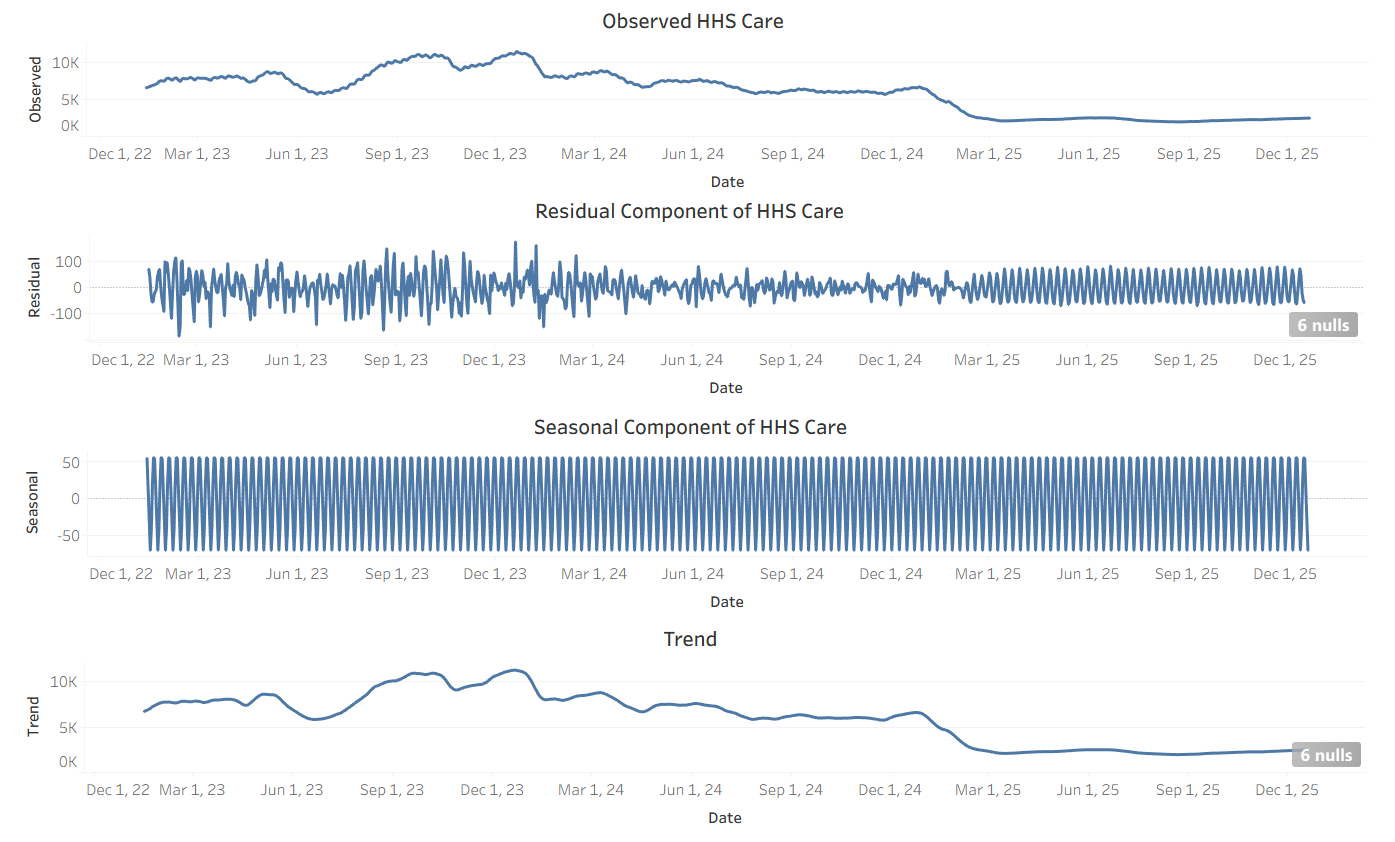

In [30]:
df_7.head()

,Date,Placed_In_CBP,CBP_Custody,CBP_To_HHS,HHS_Care,Discharged_From_HHS,Placed_In_CBP_lag_1,CBP_Custody_lag_1,CBP_To_HHS_lag_1,HHS_Care_lag_1,...,CBP_To_HHS_rolling_avg_14,HHS_Care_rolling_avg_14,Discharged_From_HHS_rolling_avg_14,Net_HHS_Flow,Net_HHS_Flow_rolling_avg_7,Net_HHS_Flow_rolling_avg_14,Net_HHS_Flow_rolling_std_7,Day_Of_Week,Month,Is_Weekend
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-402.0,NaN,NaN,NaN,3,1,0
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0,33.0,53.0,34.0,6566.0,...,NaN,NaN,NaN,-381.0,NaN,NaN,NaN,4,1,0
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0,33.0,53.0,34.0,6622.0,...,NaN,NaN,NaN,-359.0,NaN,NaN,NaN,5,1,1
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0,33.0,52.0,35.0,6677.0,...,NaN,NaN,NaN,-337.0,NaN,NaN,NaN,6,1,1
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0,33.0,52.0,36.0,6733.0,...,NaN,NaN,NaN,-316.0,NaN,NaN,NaN,0,1,0


#### Train test strategy

We will not be using traditional train-test-split in this project, because it is a time-series dataset. In such datasets, we use past and present data in order to predict future data.

We will be using walk-forward validation technique. It is a validation technique that uses past data to predict future ones, and past data is moved forward by some time and then future data is predicted. For example, the model is trained from Jan 1 2025 to December 1 2025 and tested on Jan 1 2026 to Mar 31 2026. Then we shift the thresholds by 1 week - now model is trained from Jan 7 2025 to Jan 7 2026, and tested on Jan 8 2026 to April 7 2026.

We would be using expanding window technique of walk forward validation. Each time we will expand the training set by some time and expand the testing input values by the same time. For example, the model is trained from Jan 1 2025 to December 1 2025 and tested on Jan 1 2026 to Mar 31 2026. Then we roll the training set by a week - now it is trained on Jan 7 2025 to Jan 7 2026. Testing set ranges from Jan 8 2026 to April 7 2026. This is the rolling window or conveyor belt method for validation.

There is another method of walk-forward validation, which is none other than expanding window method. Let us take an example. A model is trained from Jan 1 2025 to December 1 2025 and tested on Jan 1 2026 to Jan 7 2026. Then we expand the training set - now it is trained on Jan 1 2026 to Jan 7 2026. Testing set ranges from Jan 8 2026 to Jan 15 2026.

We need to split the dataset to training set, validation window and testing set. The following are the best percentage shares of the dataset:

* Training set - 67%
* Validation Window - 25%
* Testing set - 8%

In [31]:
initial_day = df_7.loc[0,"Date"]
final_day = df_7.loc[df_7.shape[0]-1,"Date"]

td = (final_day - initial_day)
total_number_of_days = td.days

number_of_training_dates = round(total_number_of_days * 67 / 100)
size_of_validation_window = round(total_number_of_days * 25 / 100)
number_of_testing_dates = total_number_of_days - (number_of_training_dates + size_of_validation_window)

training_threshold = initial_day + timedelta(number_of_training_dates - 1)
validation_threshold = training_threshold + timedelta(size_of_validation_window - 1)

training_dates = pd.date_range(
    initial_day,
    training_threshold,
    inclusive = "left",
)

validation_window_1 = pd.date_range(
    training_threshold,
    validation_threshold,
    inclusive = "left"
)

testing_dates = pd.date_range(
    validation_threshold,
    final_day,
    inclusive = "both"
)

The above code retrieves the training, validation, and testing dates. During walk-forward validation, we need to generate predictions for the validation data **window by window** rather than predicting one day at a time. A **validation window** refers to a fixed range of consecutive dates that the model predicts at each iteration.

For example, if we use a **7-day validation window**, we first train the model using the available training data. We then use the trained model to predict the first 7 days of the validation period. After these 7 days have passed, their **actual observed values** are added to the training data. The validation window is then moved forward by 7 days, and the model is retrained using the expanded training data before predicting the next 7 days.

This process is repeated until the entire validation period has been covered. Therefore, instead of iterating through the validation dates individually, we divide the validation dates into groups containing number of consecutive dates equal to window size. This allows us to process the validation period **window by window**, which accurately represents the walk-forward forecasting process. The following function is used to divide the validation data into fixed-size windows.

In [32]:
def retrieve_validation_window(validation_window_1,length_of_window):
	validation_data = []
	v = 0
	p = []

	for i in validation_window_1:
		if v == length_of_window:
		    t = pd.date_range(p[0],p[-1])
		    validation_data.append(t)
		    p = []
		    v = 0
		p.append(i)
		v += 1

	if p is not None:
		t = pd.date_range(p[0],p[-1])
		validation_data.append(t)

	return validation_data

#### Training Models

#### 1) Baseline Models

#####   a) Naive approach

In [33]:
def naive_model(df,start_date):
    predicted_value = df[df["Date"] == start_date]["HHS_Care_lag_1"].values[0]
    return predicted_value

In [34]:
size_of_window = 7
validation_data = retrieve_validation_window(validation_window_1,size_of_window)
cols = ["Day "+str(i) for i in range(1,size_of_window+1)]
mae_df = pd.DataFrame(columns = ["Fold"]+cols)
rmse_df = pd.DataFrame(columns = ["Fold"]+cols)
rt = 0

for i in validation_data:
    start_date = i[0]
    # print(i)
    df_train_test = pd.DataFrame(columns=["Date","Actual_HHS_Care","Predicted_HHS_Care"])

    hhs_care_predicted_value = naive_model(df_7,start_date)

    df_train_test["Date"] = i
    df_train_test["Actual_HHS_Care"] = df_7[[k in i for k in df_7["Date"]]]["HHS_Care"].values
    df_train_test["Predicted_HHS_Care"] = hhs_care_predicted_value

    cols_1 = ["Day "+str(i) for i in range(1,len(i)+1)]


    df_train_test["Absolute_Error"] = abs(df_train_test["Predicted_HHS_Care"] - df_train_test["Actual_HHS_Care"])
    mae = mean_absolute_error(df_train_test["Actual_HHS_Care"],df_train_test["Predicted_HHS_Care"])
    mae_df.loc[rt,"Fold"] = (rt + 1)
    mae_df.loc[rt,cols_1] = df_train_test["Absolute_Error"].values
    mae_df.loc[rt,"MAE"] = round(mae,2)


    df_train_test["Squared_Error"] = (df_train_test["Predicted_HHS_Care"] - df_train_test["Actual_HHS_Care"]) * (df_train_test["Predicted_HHS_Care"] - df_train_test["Actual_HHS_Care"])
    rmse = root_mean_squared_error(df_train_test["Actual_HHS_Care"],df_train_test["Predicted_HHS_Care"])
    rmse_df.loc[rt,"Fold"] = (rt + 1)
    rmse_df.loc[rt,cols_1] = df_train_test["Squared_Error"].values
    rmse_df.loc[rt,"RMSE"] = round(rmse,2)


    rt += 1

mae_horizon_error_profile = mae_df.mean()
mae_horizon_error_profile.drop(["Fold","MAE"],axis=0,inplace=True)
mae_horizon_error_profile = mae_horizon_error_profile.round(2)

rmse_horizon_error_profile = rmse_df.mean()
rmse_horizon_error_profile.drop(["Fold","RMSE"],axis=0,inplace=True)
rmse_horizon_error_profile = round(np.power(rmse_horizon_error_profile,0.5),2)

In [35]:
mae_horizon_error_profile

Day 1     14.49
Day 2     28.32
Day 3     47.45
Day 4     74.21
Day 5    101.08
Day 6    128.18
Day 7    143.71
dtype: object

In [36]:
rmse_horizon_error_profile

Day 1      25.7
Day 2     49.19
Day 3     82.51
Day 4    129.92
Day 5    179.26
Day 6    229.38
Day 7    257.57
dtype: object

##### b) Moving average forecast

In [37]:
def calculate_moving_avg(df,window_dates,window_size):
   return df[[k in window_dates for k in df["Date"]]]["HHS_Care_rolling_avg_"+str(window_size)].round(2).values

In [38]:
size_of_window = 7
validation_data = retrieve_validation_window(validation_window_1,size_of_window)
cols = ["Day "+str(i) for i in range(1,size_of_window+1)]
mae_df = pd.DataFrame(columns = ["Fold"]+cols)
rmse_df = pd.DataFrame(columns = ["Fold"]+cols)
rt = 0

for i in validation_data:
    start_date = i[0]
    # print(i)
    df_train_test = pd.DataFrame(columns=["Date","Actual_HHS_Care","Predicted_HHS_Care"])

    hhs_care_predicted_values = calculate_moving_avg(df_7,i,size_of_window)

    df_train_test["Date"] = i
    df_train_test["Actual_HHS_Care"] = df_7[[k in i for k in df_7["Date"]]]["HHS_Care"].values
    df_train_test["Predicted_HHS_Care"] = hhs_care_predicted_values

    cols_1 = ["Day "+str(i) for i in range(1,len(i)+1)]


    df_train_test["Absolute_Error"] = abs(df_train_test["Predicted_HHS_Care"] - df_train_test["Actual_HHS_Care"])
    mae = mean_absolute_error(df_train_test["Actual_HHS_Care"],df_train_test["Predicted_HHS_Care"])
    mae_df.loc[rt,"Fold"] = (rt + 1)
    mae_df.loc[rt,cols_1] = df_train_test["Absolute_Error"].values
    mae_df.loc[rt,"MAE"] = round(mae,2)


    df_train_test["Squared_Error"] = (df_train_test["Predicted_HHS_Care"] - df_train_test["Actual_HHS_Care"]) * (df_train_test["Predicted_HHS_Care"] - df_train_test["Actual_HHS_Care"])
    rmse = root_mean_squared_error(df_train_test["Actual_HHS_Care"],df_train_test["Predicted_HHS_Care"])
    rmse_df.loc[rt,"Fold"] = (rt + 1)
    rmse_df.loc[rt,cols_1] = df_train_test["Squared_Error"].values
    rmse_df.loc[rt,"RMSE"] = round(rmse,2)


    rt += 1

mae_horizon_error_profile = mae_df.mean()
mae_horizon_error_profile.drop(["Fold","MAE"],axis=0,inplace=True)
mae_horizon_error_profile = mae_horizon_error_profile.round(2)

rmse_horizon_error_profile = rmse_df.mean()
rmse_horizon_error_profile.drop(["Fold","RMSE"],axis=0,inplace=True)
rmse_horizon_error_profile = round(np.power(rmse_horizon_error_profile,0.5),2)

In [39]:
mae_horizon_error_profile

Day 1    58.92
Day 2    52.99
Day 3    55.03
Day 4     60.9
Day 5    66.93
Day 6    73.52
Day 7    69.13
dtype: object

In [40]:
rmse_horizon_error_profile

Day 1    108.49
Day 2     97.36
Day 3     95.22
Day 4    106.53
Day 5    119.97
Day 6    134.42
Day 7    126.82
dtype: object

#### 2) Statistical Models

##### a) ARIMA

In [65]:
df_7.head()

,Date,Placed_In_CBP,CBP_Custody,CBP_To_HHS,HHS_Care,Discharged_From_HHS,Placed_In_CBP_lag_1,CBP_Custody_lag_1,CBP_To_HHS_lag_1,HHS_Care_lag_1,...,CBP_To_HHS_rolling_avg_14,HHS_Care_rolling_avg_14,Discharged_From_HHS_rolling_avg_14,Net_HHS_Flow,Net_HHS_Flow_rolling_avg_7,Net_HHS_Flow_rolling_avg_14,Net_HHS_Flow_rolling_std_7,Day_Of_Week,Month,Is_Weekend
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,-402.0,NaN,NaN,NaN,3,1,0
1,2023-01-13,33.0,53.0,34.0,6622.0,415.0,33.0,53.0,34.0,6566.0,...,NaN,NaN,NaN,-381.0,NaN,NaN,NaN,4,1,0
2,2023-01-14,33.0,52.0,35.0,6677.0,394.0,33.0,53.0,34.0,6622.0,...,NaN,NaN,NaN,-359.0,NaN,NaN,NaN,5,1,1
3,2023-01-15,33.0,52.0,36.0,6733.0,373.0,33.0,52.0,35.0,6677.0,...,NaN,NaN,NaN,-337.0,NaN,NaN,NaN,6,1,1
4,2023-01-16,33.0,51.0,36.0,6788.0,352.0,33.0,52.0,36.0,6733.0,...,NaN,NaN,NaN,-316.0,NaN,NaN,NaN,0,1,0


In [50]:
df_7[["Date","HHS_Care"]].head(10)

,Date,HHS_Care
0,2023-01-12,6566.0
1,2023-01-13,6622.0
2,2023-01-14,6677.0
3,2023-01-15,6733.0
4,2023-01-16,6788.0
5,2023-01-17,6844.0
6,2023-01-18,6900.0
7,2023-01-19,6955.0
8,2023-01-20,7011.0
9,2023-01-21,7066.0


<Axes: xlabel='Date', ylabel='HHS_Care'>

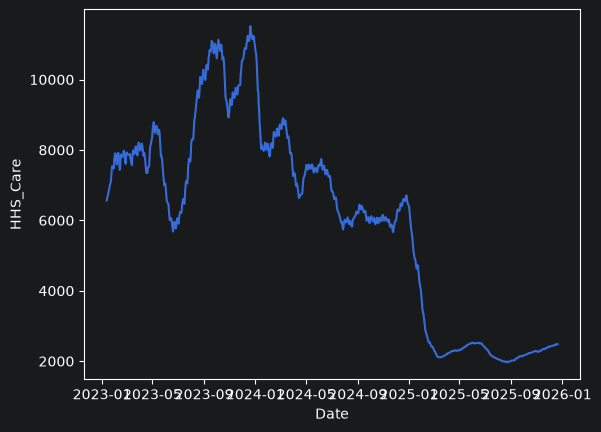

In [55]:
sns.lineplot(x=df_7["Date"],y=df_7["HHS_Care"])

In [73]:
result = adfuller(df_7["HHS_Care"])
adf = result[0]
p_value = result[1]
p_value

0.6634675498113598